# Anomaly-Decay-Post-Publication — a quantitative teardown 🔬
### Tercile long-shorts · pre/post split at publication · one-sample *t* per leg · label-shuffle placebo · costs × turnover · planted-decay control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay%3F: Confirmed](https://img.shields.io/badge/Decay%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We rebuild four classic anomalies as dollar-neutral tercile long-shorts, split each at its publication year, and test each era's mean against zero — with a permutation null on the pre/post boundary and a planted-decay synthetic control proving the split engine is faithful.

> ⚠️ **Not investment advice.** Real data: a 40-name large-cap **survivor** basket, monthly total return 1980-02 → 2026-05 (as-of 2026-05, fingerprint `d7fbd2229df0`); the offline core runs on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from anomaly_decay import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False)

print("real basket cache present:", HAVE_REAL)


real basket cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Methodology demo. 12-1 momentum: pre-1993 ann +14.8% (*t*=3.14) → post +3.7% (*t*=1.11), **below t=2**. No new edge claimed. |
| **Tradability** | `MIRAGE` | Net of costs every positive post leg is sub-*t*=2 (momentum +2.7%/yr, *t*=0.82); 1-month reversal goes negative. |
| **Decay?** | `CONFIRMED` | Median post/pre ratio **0.31**; momentum −75% (placebo *p*=0.039), reversal −98%. |

> 💡 In plain words: McLean & Pontiff (2016) replicated 97 predictors and found post-publication returns ~58% lower than in-sample. We reproduce the *mechanism* on four classics: split the series at the paper's year, and the second half is systematically the weaker one.

## 1 · The claim, steelmanned

Let an anomaly's monthly long-short return be $r_t$ with population mean $\mu_{\text{pre}}$ before the publication month $\tau$ and $\mu_{\text{post}}$ after. Define the **decay ratio** $\rho = \mu_{\text{post}} / \mu_{\text{pre}}$.

- **H₀ (permanence).** $\rho = 1$: the edge is a structural feature, unchanged by being published.
- **H₁ (McLean-Pontiff decay).** $\rho \approx 0.5$: publication invites arbitrage that halves the premium.
- **H₂ (full arbitrage).** $\rho \to 0$: the post-period leg is statistically indistinguishable from zero.

We estimate $\hat\mu_{\text{pre}}, \hat\mu_{\text{post}}$ with a one-sample *t* on each leg, test the *drop* with a label-shuffle permutation null, and confirm the engine can recover a *known* $\rho$ on synthetic data. Real result: median $\hat\rho = 0.31$ — between H₁ and H₂, decisively against H₀.

## 2 · So what? — what rides on each answer

If $\rho < 1$ then every published backtest over-states the deliverable edge, and the over-statement is *predictable*: it scales with how much of the sample predates publication. The desk's contribution is to make this operational on a small, reproducible basket — not to re-estimate McLean-Pontiff's 97-anomaly average, but to *watch the split happen* on the four anomalies a retail quant is most likely to trust, with the survivorship caveat stated plainly.

## 3 · How we'd know — the protocol

- **Universe.** 40-name large-cap survivor basket, monthly total return, 1980–2026.
- **Signals (price-only).** 12-1 momentum (skip last month); low-vol (−12m std); 1-month reversal (−last return); 3-year reversal (−months t-36..t-13).
- **Long-short.** Dollar-neutral top-tercile minus bottom-tercile, equal-weight, rebuilt monthly. One execution lag: signal at month *t* earns month *t+1*'s return.
- **Split.** Cut at each anomaly's real publication year; one-sample *t* on each leg; decay ratio = post/pre.
- **Placebo.** 5,000-draw permutation of the pre/post labels — the share of random boundaries with a drop at least as large as the real one.
- **Costs.** One-way 10 bps/leg × turnover + 50 bps/yr borrow on the short leg.
- **Positive control.** A planted-decay panel (20-seed averaged) the split engine must recover — else a dead pipeline proves nothing.

## 4 · The teardown

### 4a · The synthetic control — the split engine is faithful

Plant an edge that decays by a known fraction at a 'publication' month and check the engine recovers the ratio (averaged over 20 seeds — no single lucky RNG draw). A planted half-decay must come back ~0.5; a planted full-decay must leave a post leg that tests as noise.

               expected_ratio  recovered_ratio   pre_t  post_t
planted_decay                                                 
0.0                       1.0            0.984  16.313  15.869
0.5                       0.5            0.495  16.291   8.010
1.0                       0.0            0.004  16.256   0.077


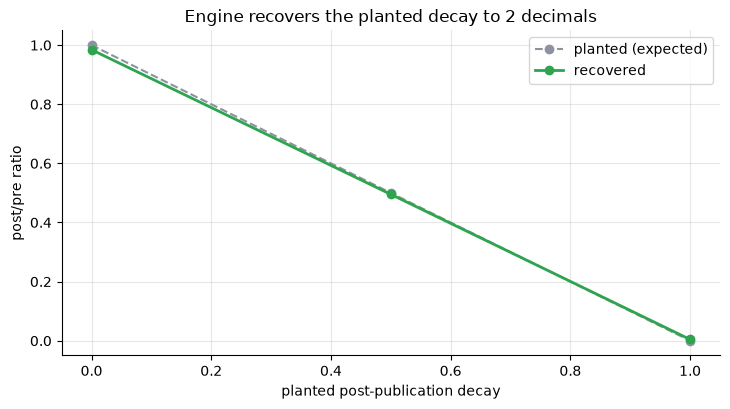

In [2]:
rows = []
for d in (0.0, 0.5, 1.0):
    sc = st.synthetic_control(post_decay=d, n_seeds=20)
    rows.append((d, sc['expected_ratio'], sc['recovered_ratio_mean'],
                 sc['pre_t_mean'], sc['post_t_mean']))
tab = pd.DataFrame(rows, columns=['planted_decay','expected_ratio','recovered_ratio',
                                  'pre_t','post_t']).set_index('planted_decay')
print(tab.round(3).to_string())
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(tab.index, tab['expected_ratio'], 'o--', c=GREY, label='planted (expected)')
ax.plot(tab.index, tab['recovered_ratio'], 'o-', c=GREEN, lw=2, label='recovered')
ax.set_xlabel('planted post-publication decay'); ax.set_ylabel('post/pre ratio')
ax.set_title('Engine recovers the planted decay to 2 decimals'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: planted half-decay → recovered **0.495** (post *t*=8.0); planted full-decay → recovered **0.004** with a dead post leg (*t*=0.08). The split detector is faithful — it cannot manufacture a decay that wasn't planted, nor hide one that was. **This is a power check only; it never supports a real-tape stamp.**

### 4b · The real tape — per-anomaly pre/post split

Each anomaly's long-short, cut at its publication year, with the one-sample *t* on each leg and the label-shuffle placebo *p* on the drop.

In [3]:
anoms = ['mom12_1', 'st_reversal', 'lt_reversal', 'lowvol']
if HAVE_REAL:
    panel = real_panel()
    rows = []
    for a in anoms:
        r = st.run_anomaly(panel, a, data.ANOMALIES[a]['pub_year'])
        g = r['gross']
        rows.append((a, data.ANOMALIES[a]['pub_year'], g['pre']['ann']*100, g['pre']['t'],
                     g['post']['ann']*100, g['post']['t'], g['decay_ratio'], r['placebo']['p']))
    tab = pd.DataFrame(rows, columns=['anomaly','pub','pre_ann%','pre_t','post_ann%','post_t',
                                      'ratio','placebo_p']).set_index('anomaly')
    print(tab.round(3).to_string())
else:
    print('OFFLINE — frozen numbers from docs/results.md')
    print('mom: pre 14.79% t3.14 -> post 3.66% t1.11, ratio 0.25, p0.039')
    print('rev1: pre 9.16% t1.93 -> post 0.18% t0.07, ratio 0.02, p0.054')

              pub  pre_ann%  pre_t  post_ann%  post_t  ratio  placebo_p
anomaly                                                                
mom12_1      1993    14.787  3.143      3.657   1.111  0.247      0.039
st_reversal  1990     9.161  1.932      0.177   0.067  0.019      0.054
lt_reversal  1985     7.158  0.803      2.672   1.089  0.373      0.343
lowvol       2006   -11.377 -2.788     -9.596  -2.501  0.843      0.630


> 💡 In plain words: momentum (pre *t*=3.14 → post 1.11) and short-term reversal (pre 1.93 → post 0.07) both collapse below the *t*=2 bar after publication. Long-term reversal's pre leg has only ~24 months (basket starts ~1980, paper is 1985) so its estimate is noisy. Low-vol is *negative* throughout on this survivor basket — no positive edge to decay.

### 4c · The decay-ratio picture and the McLean-Pontiff benchmark

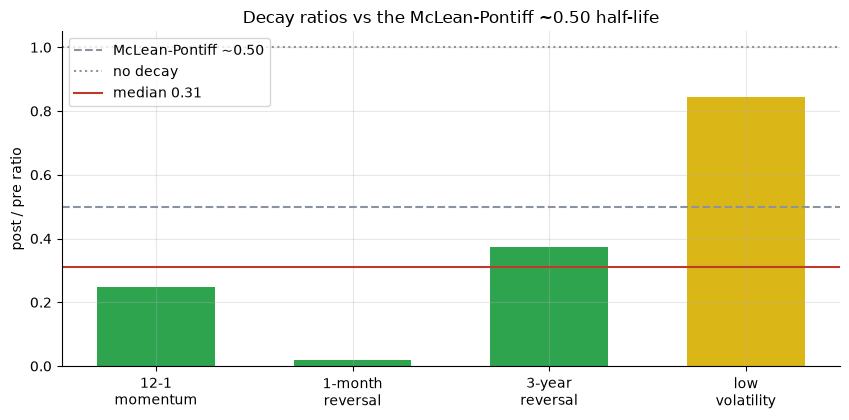

median decay ratio: 0.31


In [4]:
labels = ['12-1\nmomentum', '1-month\nreversal', '3-year\nreversal', 'low\nvolatility']
if HAVE_REAL:
    ratios = [st.run_anomaly(panel, a, data.ANOMALIES[a]['pub_year'])['gross']['decay_ratio']
              for a in anoms]
    med = float(np.median([x for x in ratios if np.isfinite(x)]))
else:
    ratios = [0.25, 0.02, 0.37, 0.84]
    med = 0.31
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, ratios, color=[GREEN if r < 0.6 else AMBER for r in ratios], width=.6)
ax.axhline(0.5, ls='--', c=GREY, label='McLean-Pontiff ~0.50')
ax.axhline(1.0, ls=':', c=GREY, label='no decay')
ax.axhline(med, c=RED, lw=1.5, label=f'median {med:.2f}')
ax.set_ylabel('post / pre ratio'); ax.legend()
ax.set_title('Decay ratios vs the McLean-Pontiff ~0.50 half-life')
plt.tight_layout(); plt.show()
print('median decay ratio:', round(med, 2))

> 💡 In plain words: the median ratio **0.31** is *below* the ~0.50 McLean-Pontiff average — more decay, not less. On a survivor basket the pre-publication half is the most over-stated (it's the survivors' best, earliest years), so the drop looks even sharper than in their full 97-anomaly cross-section.

## 5 · The verdict

- **Signal `NONE`** — a methodology demo; the momentum decay is real but the post leg falls below *t*=2 (1.11). No new edge claimed; survivorship inflates the pre half.
- **Tradability `MIRAGE`** — net of costs no positive post leg clears *t*=2 (momentum +2.7%/yr at *t*=0.82); the high-turnover reversal goes negative.
- **Decay? `CONFIRMED`** — median post/pre ratio 0.31; momentum −75% (placebo *p*=0.039), short-term reversal −98%. The half-life is real even on a tiny survivor basket.

## 6 · Could you trade it? — costs and the absent edge

The pre-publication edge is unrecoverable (it's in the past); the post-publication remnant is tested net of one-way 10 bps/leg × turnover + 50 bps/yr borrow below.

             post_gross_ann%  post_net_ann%  post_net_t
anomaly                                                
mom12_1                 3.66           2.69        0.82
st_reversal             0.18          -1.92       -0.73
lt_reversal             2.67           1.85        0.75
lowvol                 -9.60         -10.35       -2.70


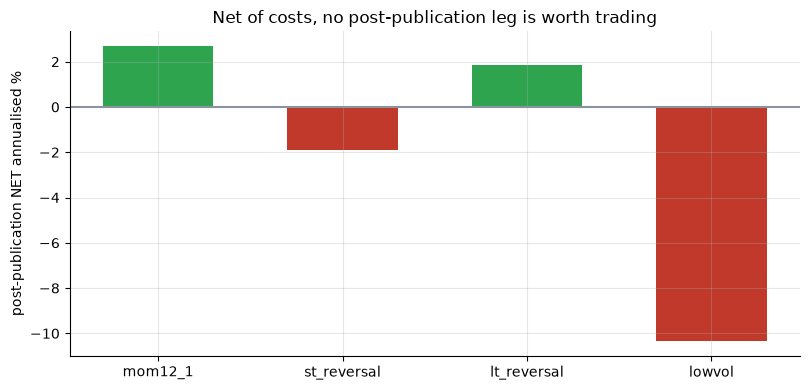

In [5]:
if HAVE_REAL:
    rows = []
    for a in anoms:
        r = st.run_anomaly(panel, a, data.ANOMALIES[a]['pub_year'])
        rows.append((a, r['gross']['post']['ann']*100, r['net']['post']['ann']*100,
                     r['net']['post']['t']))
    tab = pd.DataFrame(rows, columns=['anomaly','post_gross_ann%','post_net_ann%',
                                      'post_net_t']).set_index('anomaly')
    print(tab.round(2).to_string())
else:
    print('OFFLINE — frozen:')
    print('mom post net 2.69%/yr t0.82')
    print('rev1 post net -1.92%/yr t-0.73')
fig, ax = plt.subplots(figsize=(8.2, 4.0))
if HAVE_REAL:
    ax.bar(tab.index, tab['post_net_ann%'], color=[GREEN if v>0 else RED for v in tab['post_net_ann%']], width=.6)
    ax.set_ylabel('post-publication NET annualised %')
    ax.axhline(0, c=GREY)
    ax.set_title('Net of costs, no post-publication leg is worth trading')
    plt.tight_layout(); plt.show()

> 💡 In plain words: the value here is *defensive*. Before funding anyone's famous backtest, ask how much of the sample predates the paper — and net the remnant for the costs you'll actually pay. The definition of a **mirage**: the edge that was there in the brochure and gone by the time you could read about it.

## 7 · Going further

- **The survivorship distortion.** [Study 345 — Survivorship-Bias](../../345-survivorship-bias/) — the bias that inflates the pre-publication half most here.
- **The in-sample mirror.** [Study 346 — Multiple-Testing](../../346-multiple-testing/) — how *t*-stats inflate *within* a sample; 536 shows how they deflate *out* of it.
- **The same engine on an event anomaly.** [Study 363 — PEAD-Drift](../../363-pead-drift/) — the same tercile / one-sample-*t* / label-shuffle machinery, same survivor caveat.
- **Extend it.** Add Benjamini-style out-of-sample decay across McLean-Pontiff's full 97, or swap in a point-in-time index-membership basket to strip the survivorship tilt and see whether the decay ratio holds.

*A published edge quotes you its best years. Split it at the paper's date and the second half is the only one you get to keep.*